In [8]:
#SecureTrustBank system  ------
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection  import train_test_split 

In [9]:
df = pd.read_csv("loan_approval_data.csv")

In [10]:
# Data preprocessing
# df.head()
# df.info()
#df.isnull().sum()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# Handel missing values 


In [11]:
#for categorical columns we use 
categorical_columns = df.select_dtypes(include="object").columns #categorical columns are always object 
numerical_columns = df.select_dtypes(include=["float64"]).columns # they are int64 or float64 

In [12]:
categorical_columns
numerical_columns
df[numerical_columns]

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,58.0,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0
996,997.0,3279.0,6356.0,58.0,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0
997,998.0,15192.0,8433.0,48.0,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0
998,999.0,9083.0,7380.0,50.0,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0


In [13]:
# to handle missing values we use Imputer # it also want numpy 
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy="mean")
df[numerical_columns] = num_imp.fit_transform(df[numerical_columns]) # replace with mean

In [15]:
df[numerical_columns]

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
0,1.0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0
1,2.0,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0
2,3.0,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0
3,4.0,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0
4,5.0,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0
996,997.0,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0
997,998.0,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0
998,999.0,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   950 non-null    object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [17]:
df[categorical_columns]

,Employment_Status,Marital_Status,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,Salaried,Married,Personal,Urban,Not Graduate,Female,Private,No
1,Salaried,Married,Car,Semiurban,Graduate,NaN,Private,No
2,Salaried,Single,NaN,Urban,NaN,Female,Government,Yes
3,Salaried,Married,Business,Rural,Graduate,Female,Government,No
4,Self-employed,Single,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...
995,Salaried,Married,Personal,NaN,Not Graduate,Male,Unemployed,No
996,Self-employed,Married,Business,Urban,Graduate,Female,Government,No
997,Contract,Single,Home,Rural,Graduate,Male,MNC,No
998,Unemployed,Single,Personal,Urban,Graduate,Male,Private,Yes


In [18]:
categorical_imp = SimpleImputer(strategy="most_frequent") # replace with most frequent one 
df[categorical_columns] = categorical_imp.fit_transform(df[categorical_columns]) # use fit_transform 

In [19]:
df[categorical_columns]

,Employment_Status,Marital_Status,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,Salaried,Married,Personal,Urban,Not Graduate,Female,Private,No
1,Salaried,Married,Car,Semiurban,Graduate,Male,Private,No
2,Salaried,Single,Business,Urban,Graduate,Female,Government,Yes
3,Salaried,Married,Business,Rural,Graduate,Female,Government,No
4,Self-employed,Single,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...
995,Salaried,Married,Personal,Urban,Not Graduate,Male,Unemployed,No
996,Self-employed,Married,Business,Urban,Graduate,Female,Government,No
997,Contract,Single,Home,Rural,Graduate,Male,MNC,No
998,Unemployed,Single,Personal,Urban,Graduate,Male,Private,Yes


In [20]:
df.info() # zero null value it means 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [21]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA : Explorator Data Analysis 

In [22]:
# approved or not approved 
approved_count = df["Loan_Approved"].value_counts()

Text(0.5, 1.0, 'Approved or Not Approved Loan ?')

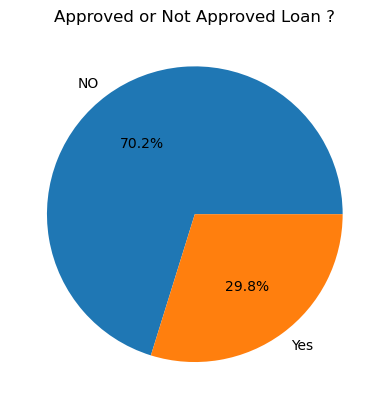

In [23]:
plt.pie(approved_count ,labels=["NO","Yes"] , autopct="%1.1f%%")
plt.title("Approved or Not Approved Loan ?")

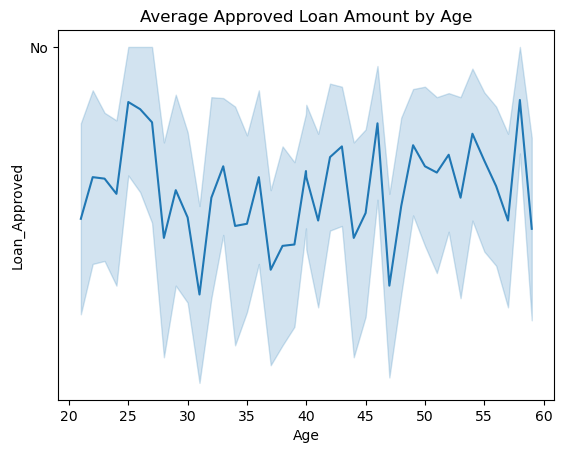

In [24]:
# Plots the average loan amount per age with a shaded error band
sns.lineplot(data=df, x="Age", y="Loan_Approved")

plt.title("Average Approved Loan Amount by Age")
plt.show()


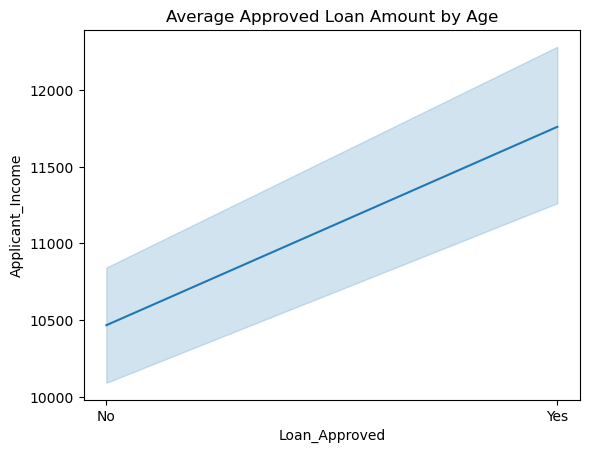

In [25]:
sns.lineplot(data=df, y="Applicant_Income", x="Loan_Approved")

plt.title("Average Approved Loan Amount by Age")
plt.show()

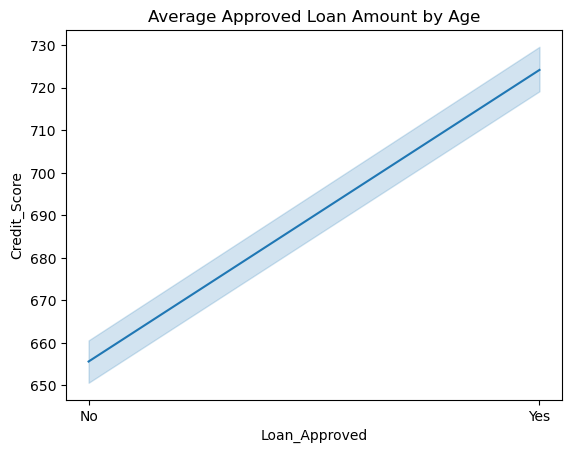

In [26]:
# Plots the average loan amount per age with a shaded error band
sns.lineplot(data=df, y="Credit_Score", x="Loan_Approved")

plt.title("Average Approved Loan Amount by Age")
plt.show()


[Text(0, 0, '621'), Text(0, 0, '379')]

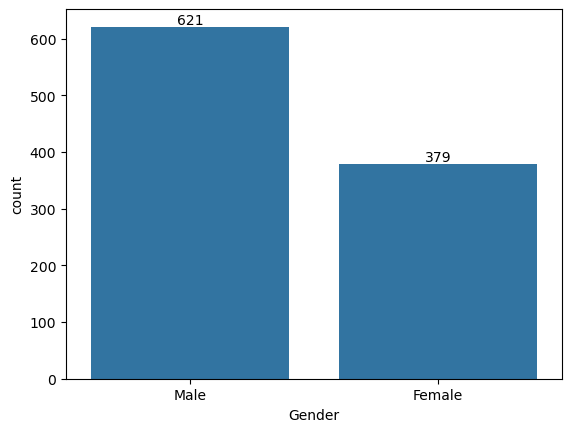

In [27]:
gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Credit_Score', ylabel='Count'>

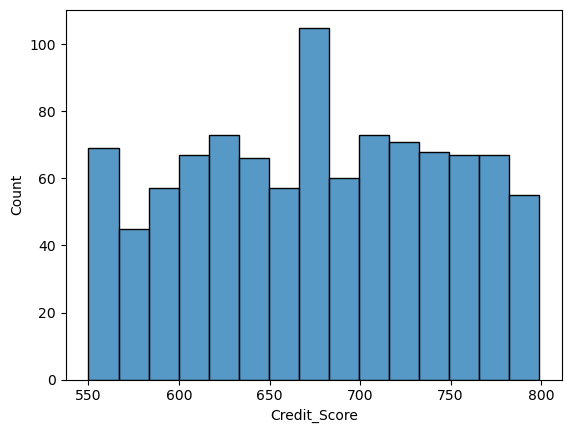

In [28]:
sns.histplot(
    data= df ,
    x = "Credit_Score",
    bins =15
    
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

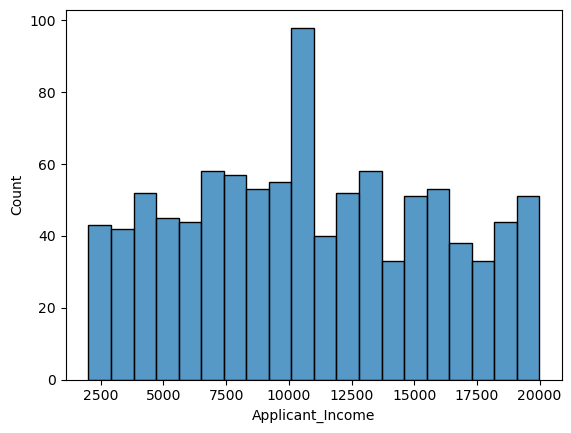

In [29]:
#income vs approved loan 
sns.histplot(
    data =df ,
    x = "Applicant_Income",
    bins = 20 )
   


<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

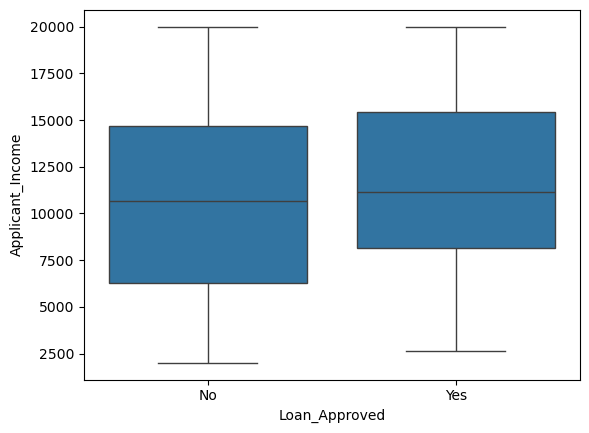

In [30]:
sns.boxplot(
    data =df ,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

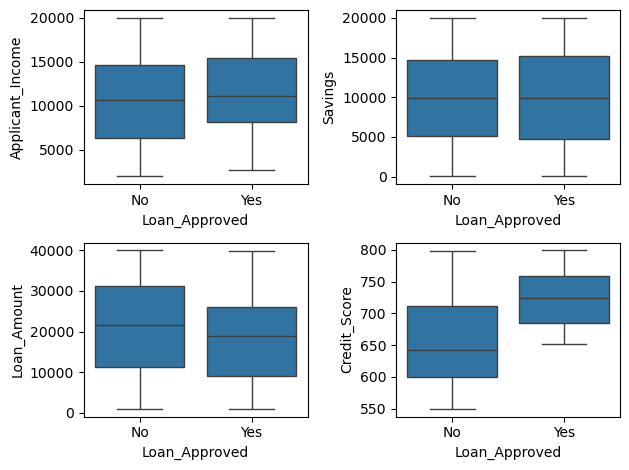

In [36]:
fig , axes = plt.subplots(2,2)
sns.boxplot( ax = axes[0,0], data =df , x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot( ax = axes[0,1], data =df , x = "Loan_Approved", y = "Savings")
sns.boxplot( ax = axes[1,0], data =df , x = "Loan_Approved", y = "Loan_Amount")
sns.boxplot( ax = axes[1,1], data =df , x = "Loan_Approved", y = "Credit_Score")
plt.tight_layout()

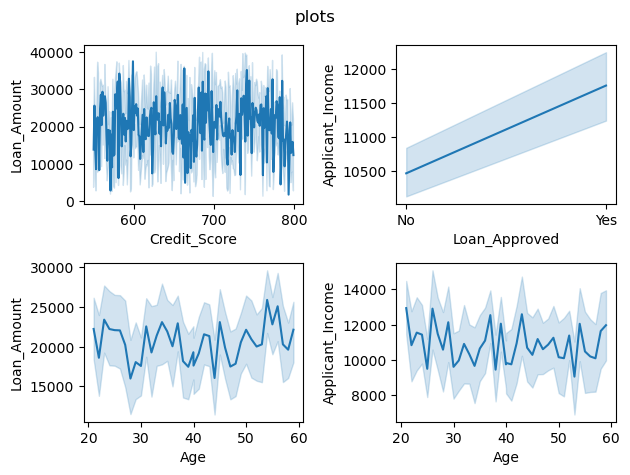

In [51]:
fig ,axes = plt.subplots(2,2)
sns.lineplot(ax = axes[0,0] ,data = df , x ="Credit_Score", y ="Loan_Amount" )
sns.lineplot(ax = axes[0,1] ,data = df , y="Applicant_Income", x="Loan_Approved" )
sns.lineplot(ax = axes[1,0] ,data = df , x ="Age", y ="Loan_Amount" )
sns.lineplot(ax = axes[1,1] ,data = df , x ="Age", y ="Applicant_Income" )

plt.suptitle("plots")
plt.tight_layout()

In [54]:
df.max() , df.min()

(Applicant_ID                1000.0
 Applicant_Income           19988.0
 Coapplicant_Income          9996.0
 Employment_Status       Unemployed
 Age                           59.0
 Marital_Status              Single
 Dependents                     3.0
 Credit_Score                 799.0
 Existing_Loans                 4.0
 DTI_Ratio                      0.6
 Savings                    19996.0
 Collateral_Value           49954.0
 Loan_Amount                39995.0
 Loan_Term                     84.0
 Loan_Purpose              Personal
 Property_Area                Urban
 Education_Level       Not Graduate
 Gender                        Male
 Employer_Category       Unemployed
 Loan_Approved                  Yes
 dtype: object,
 Applicant_ID               1.0
 Applicant_Income        2009.0
 Coapplicant_Income         1.0
 Employment_Status     Contract
 Age                       21.0
 Marital_Status         Married
 Dependents                 0.0
 Credit_Score             550.0
 Existin

<Axes: xlabel='Credit_Score', ylabel='Count'>

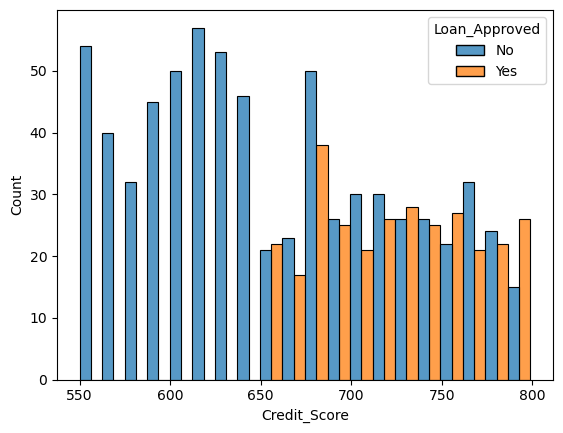

In [57]:
sns.histplot(data=df , x="Credit_Score",bins=20 ,hue="Loan_Approved",multiple="dodge")

<Axes: xlabel='Loan_Purpose', ylabel='count'>

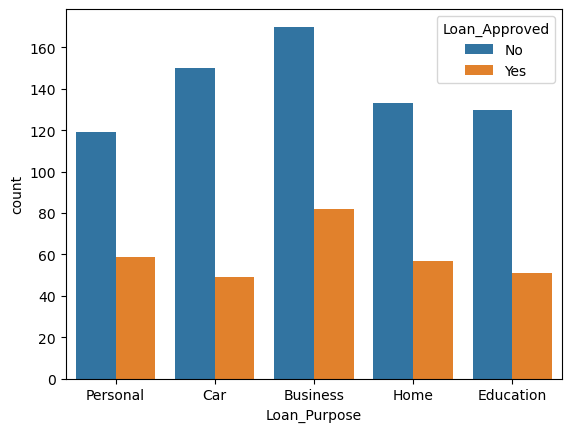

In [84]:
sns.countplot( data = df , x = "Loan_Purpose",hue="Loan_Approved")